# Embedding vectors for images

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
arr = np.zeros(shape=(7,5))
arr

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [3]:
three = arr.copy()
three[1:6, 3] = 255
three[range(1, 6, 2), 1] = 255
three[range(1, 6, 2), 2] = 255
three

array([[  0.,   0.,   0.,   0.,   0.],
       [  0., 255., 255., 255.,   0.],
       [  0.,   0.,   0., 255.,   0.],
       [  0., 255., 255., 255.,   0.],
       [  0.,   0.,   0., 255.,   0.],
       [  0., 255., 255., 255.,   0.],
       [  0.,   0.,   0.,   0.,   0.]])

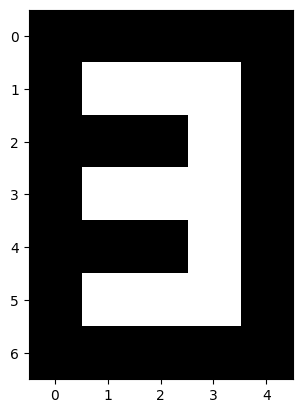

In [4]:
plt.imshow(three, cmap="gray")
plt.show()

In [5]:
three.reshape(-1)

array([  0.,   0.,   0.,   0.,   0.,   0., 255., 255., 255.,   0.,   0.,
         0.,   0., 255.,   0.,   0., 255., 255., 255.,   0.,   0.,   0.,
         0., 255.,   0.,   0., 255., 255., 255.,   0.,   0.,   0.,   0.,
         0.,   0.])

In [6]:
small_three = three[1:-1, 1:-1].copy()
small_three

array([[255., 255., 255.],
       [  0.,   0., 255.],
       [255., 255., 255.],
       [  0.,   0., 255.],
       [255., 255., 255.]])

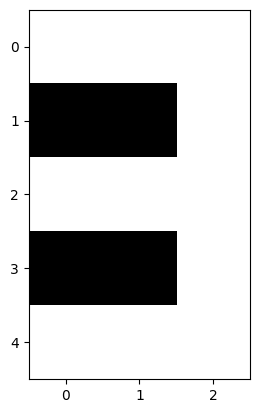

In [7]:
plt.imshow(small_three, cmap="gray")
plt.show()

In [8]:
small_three.shape

(5, 3)

In [9]:
small_three.reshape(-1)

array([255., 255., 255.,   0.,   0., 255., 255., 255., 255.,   0.,   0.,
       255., 255., 255., 255.])

In [10]:
small_three.reshape(-1).shape

(15,)

# Embedding vectors for TEXT

In [11]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
corpus = ['Early to bed', 'Early to rise', 'Makes a person', 'Healthy wealthy and wise']
corpus

['Early to bed', 'Early to rise', 'Makes a person', 'Healthy wealthy and wise']

Call the CountVectorizer class from scikit-learn (alias sklearn)

In [13]:
cv = CountVectorizer()
cv

CountVectorizer()

We will get a sparse matrix with this

To convert this numpy sparse matrix to a row and column array, we will use toarray() method of numpy sparse matrix.

In [14]:
X1 = cv.fit_transform(corpus)
X1

<4x10 sparse matrix of type '<class 'numpy.int64'>'
	with 12 stored elements in Compressed Sparse Row format>

In [15]:
X1 = X1.toarray()
X1

array([[0, 1, 1, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0, 1, 1]])

Let's understand what this array of features actually convey.

But before that, take a look at the feature names now.

In [16]:
cv.get_feature_names_out()

array(['and', 'bed', 'early', 'healthy', 'makes', 'person', 'rise', 'to',
       'wealthy', 'wise'], dtype=object)

Now, lets see how count vectorizer works

In [17]:
corpus

['Early to bed', 'Early to rise', 'Makes a person', 'Healthy wealthy and wise']

### Transformed corpus using count vectorizer

In [18]:
transformed_cv = pd.DataFrame(X1, columns=cv.get_feature_names_out())
transformed_cv["whole string"] = corpus

In [19]:
transformed_cv

,and,bed,early,healthy,makes,person,rise,to,wealthy,wise,whole string
0,0,1,1,0,0,0,0,1,0,0,Early to bed
1,0,0,1,0,0,0,1,1,0,0,Early to rise
2,0,0,0,0,1,1,0,0,0,0,Makes a person
3,1,0,0,1,0,0,0,0,1,1,Healthy wealthy and wise


In [20]:
transformed_cv.head(1)

,and,bed,early,healthy,makes,person,rise,to,wealthy,wise,whole string
0,0,1,1,0,0,0,0,1,0,0,Early to bed


In [21]:
# early to bed

# 0 1 1 0 0 0 0 1 0 0 
# bed early to

# this is good
# good is this

In [22]:
cv2 = CountVectorizer(ngram_range=(1, 2))

In [23]:
X2 = cv2.fit_transform(corpus).toarray()
X2

array([[0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]])

In [24]:
transformed_cv2 = pd.DataFrame(X2, columns=cv2.get_feature_names_out())
transformed_cv2["whole string"] = corpus

In [25]:
transformed_cv2

,and,and wise,bed,early,early to,healthy,healthy wealthy,makes,makes person,person,rise,to,to bed,to rise,wealthy,wealthy and,wise,whole string
0,0,0,1,1,1,0,0,0,0,0,0,1,1,0,0,0,0,Early to bed
1,0,0,0,1,1,0,0,0,0,0,1,1,0,1,0,0,0,Early to rise
2,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,Makes a person
3,1,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,Healthy wealthy and wise


In [26]:
cv3 = CountVectorizer(ngram_range=(1,3))
X3 = cv3.fit_transform(corpus).toarray()
X3

array([[0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]])

In [27]:
transformed_cv3 = pd.DataFrame(X3, columns=cv3.get_feature_names_out())
transformed_cv3["whole string"] = corpus

In [28]:
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [29]:
transformed_cv3

,and,and wise,bed,early,early to,early to bed,early to rise,healthy,healthy wealthy,healthy wealthy and,makes,makes person,person,rise,to,to bed,to rise,wealthy,wealthy and,wealthy and wise,wise,whole string
0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,Early to bed
1,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,0,1,0,0,0,0,Early to rise
2,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,Makes a person
3,1,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,1,1,1,Healthy wealthy and wise


## Tf-Idf vectorization

In [30]:
tf_trigram = TfidfVectorizer(ngram_range=(1,3))
X4 = tf_trigram.fit_transform(corpus).toarray()
transformed_tf = pd.DataFrame(X4, columns=tf_trigram.get_feature_names_out())
transformed_tf["whole string"] = corpus
transformed_tf

,and,and wise,bed,early,early to,early to bed,early to rise,healthy,healthy wealthy,healthy wealthy and,makes,makes person,person,rise,to,to bed,to rise,wealthy,wealthy and,wealthy and wise,wise,whole string
0,0.000000,0.000000,0.453386,0.357455,0.357455,0.453386,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.357455,0.453386,0.000000,0.000000,0.000000,0.000000,0.000000,Early to bed
1,0.000000,0.000000,0.000000,0.357455,0.357455,0.000000,0.453386,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.453386,0.357455,0.000000,0.453386,0.000000,0.000000,0.000000,0.000000,Early to rise
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.57735,0.57735,0.57735,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Makes a person
3,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.333333,Healthy wealthy and wise


# EMBEDDINGS & GloVe TUTORIAL

In [31]:
# =========================================
# EMBEDDINGS & GloVe TUTORIAL (COMPLETE)
# =========================================

# This tutorial walks step-by-step through:
# 1. What embeddings are
# 2. How text is converted into vectors
# 3. Simple embedding creation
# 4. Using pre-trained embeddings (GloVe)
# 5. Understanding each transformation step

# -----------------------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------------------

import numpy as np
from collections import Counter

# -----------------------------------------
# STEP 2: SAMPLE TEXT DATA
# -----------------------------------------

sentences = [
    "I love machine learning",
    "I love deep learning",
    "machine learning is fun"
]

# -----------------------------------------
# STEP 3: TOKENIZATION
# -----------------------------------------

# Convert sentences into words (tokens)
# This is the FIRST step in converting text to vectors

tokenized_sentences = [sentence.lower().split() for sentence in sentences]
print("Tokenized Sentences:")
print(tokenized_sentences)

Tokenized Sentences:
[['i', 'love', 'machine', 'learning'], ['i', 'love', 'deep', 'learning'], ['machine', 'learning', 'is', 'fun']]


In [32]:
# -----------------------------------------
# STEP 4: BUILD VOCABULARY
# -----------------------------------------

# Create a vocabulary (unique words)

all_words = [word for sentence in tokenized_sentences for word in sentence]
vocab = sorted(set(all_words))

# Assign index to each word
word_to_index = {word: i for i, word in enumerate(vocab)}
index_to_word = {i: word for word, i in word_to_index.items()}

print("\nVocabulary:")
print(word_to_index)


Vocabulary:
{'deep': 0, 'fun': 1, 'i': 2, 'is': 3, 'learning': 4, 'love': 5, 'machine': 6}


In [33]:
# -----------------------------------------
# STEP 5: ONE-HOT ENCODING (BASIC VECTORS)
# -----------------------------------------

# Each word becomes a vector of size = vocab size
# Only one position = 1, rest = 0

def one_hot(word):
    vector = np.zeros(len(vocab))
    vector[word_to_index[word]] = 1
    return vector

print("\nOne-hot example for 'learning':")
print(one_hot("learning"))


One-hot example for 'learning':
[0. 0. 0. 0. 1. 0. 0.]


In [34]:
# -----------------------------------------
# HOW A SENTENCE BECOMES VECTORS
# -----------------------------------------

# Step-by-step transformation:
# "I love machine learning"
# -> ["i", "love", "machine", "learning"]
# -> each word → one-hot vector
# -> sentence = list of vectors

import pandas as pd

sentence_words = tokenized_sentences[0]
sentence_vectors = [one_hot(word) for word in sentence_words]

# Create a DataFrame where:
# - Each ROW = a word in the sentence
# - Each COLUMN = a position in the vocabulary vector
# This helps visualize how a sentence is represented numerically

df = pd.DataFrame(sentence_vectors, columns=vocab, index=sentence_words)

print("Sentence as DataFrame (rows = words, columns = vocab positions):")
df

Sentence as DataFrame (rows = words, columns = vocab positions):


,deep,fun,i,is,learning,love,machine
i,0.0,0.0,1.0,0.0,0.0,0.0,0.0
love,0.0,0.0,0.0,0.0,0.0,1.0,0.0
machine,0.0,0.0,0.0,0.0,0.0,0.0,1.0
learning,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [35]:
# -----------------------------------------
# INTERPRETATION
# -----------------------------------------

# Each row = one word
# Each column = a word from the vocabulary
# Value = 1 means that word is active at that position

# So the sentence is NOT a single vector yet -
# it is a SEQUENCE of vectors (one per word)

# To make a single sentence vector:
# we usually combine them (e.g., average)

sentence_vector_avg = df.values.mean(axis=0)

print("Single sentence vector (average of rows):")
print(sentence_vector_avg)

Single sentence vector (average of rows):
[0.   0.   0.25 0.   0.25 0.25 0.25]


In [36]:
# -----------------------------------------
# LIMITATION OF ONE-HOT
# -----------------------------------------

# - Sparse (mostly zeros)
# - No semantic meaning ("love" and "like" are unrelated numerically)

# -----------------------------------------
# STEP 6: SIMPLE EMBEDDINGS (LEARNED)
# -----------------------------------------

# Instead of large sparse vectors, we use dense vectors
# Example: embedding size = 4

embedding_dim = 4

# Randomly initialize embedding matrix
embedding_matrix = np.random.rand(len(vocab), embedding_dim)

# Function to get embedding for a word

def get_embedding(word):
    return embedding_matrix[word_to_index[word]]

print("\nEmbedding for 'learning':")
print(get_embedding("learning"))


Embedding for 'learning':
[0.54329461 0.57475506 0.84584712 0.18102721]


In [37]:
# -----------------------------------------
# SENTENCE → EMBEDDING PROCESS
# -----------------------------------------

# "I love machine learning"
# -> tokenize
# -> lookup embeddings
# -> combine (average/sum)

sentence = tokenized_sentences[0]
embeddings = np.array([get_embedding(word) for word in sentence])

# Average embedding (common technique)
sentence_embedding = np.mean(embeddings, axis=0)

print("\nSentence embedding (average):")
print(sentence_embedding)


Sentence embedding (average):
[0.59757869 0.75001016 0.72049372 0.30183945]


In [38]:
# -----------------------------------------
# STEP 7: INTRODUCTION TO GloVe
# -----------------------------------------

# GloVe = Global Vectors for Word Representation
# Pre-trained on large corpora
# Captures semantic relationships

# Example:
# king - man + woman ≈ queen

# -----------------------------------------
# STEP 8: LOAD GLOVE EMBEDDINGS
# -----------------------------------------

# NOTE: You must download GloVe file manually into ../datasets 
# https://nlp.stanford.edu/projects/glove/

# Example file: glove.6B.50d.txt

# We'll simulate loading a few vectors for demo

# Format of GloVe file:
# word val1 val2 val3 ...

# Example loader:

import numpy as np

def load_glove(file_path):
    glove_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            glove_dict[word] = vector
    return glove_dict

# Uncomment when file available:
glove = load_glove("../datasets/glove.6B.50d.txt")

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/glove.6B.50d.txt'

In [ ]:
tokenized_sentences[0]

['i', 'love', 'machine', 'learning']

In [ ]:
# Example (simulated dictionary)

glove = {
    "i": np.random.rand(50),
    "love": np.random.rand(50),
    "machine": np.random.rand(50),
    "learning": np.random.rand(50)
}

# Convert sentence using GloVe

def sentence_to_glove(sentence):
    vectors = [glove[word] for word in sentence if word in glove]
    return np.mean(vectors, axis=0)

print("\nGloVe sentence embedding:")
print(sentence_to_glove(tokenized_sentences[0]))


GloVe sentence embedding:
[0.69563138 0.34140288 0.38813717 0.69906133 0.64981008 0.65982411
 0.30781142 0.66403958 0.51324121 0.63790584 0.3036328  0.50807332
 0.65598617 0.58524639 0.31849782 0.3680781  0.43269395 0.63531403
 0.5415867  0.37661252 0.49360365 0.36666192 0.19096357 0.49929238
 0.54098938 0.47281504 0.60295804 0.61350962 0.37739279 0.32263523
 0.64404827 0.30198929 0.50835469 0.51012688 0.76326134 0.39191583
 0.56962997 0.3070738  0.3962676  0.50432343 0.46421006 0.51214749
 0.47486568 0.38812231 0.54032576 0.55593843 0.7859546  0.47067767
 0.52249425 0.45768273]


In [ ]:
# -----------------------------------------
# STEP 10: WHY GLOVE IS BETTER
# -----------------------------------------

# - Captures meaning
# - Words with similar meaning have similar vectors
# - Pre-trained on huge datasets

# -----------------------------------------
# FULL PIPELINE SUMMARY
# -----------------------------------------

# Sentence → Lowercase → Tokenize
# → Vocabulary lookup
# → Convert to vectors (one-hot or embeddings)
# → Combine vectors (average, sum, etc.)
# → Final numeric representation

# -----------------------------------------
# END OF TUTORIAL
# -----------------------------------------

print("\nTutorial Complete!")


Tutorial Complete!
